In [77]:
import pandas as pd
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

all_sequences_path = Path('../data/all_sequences.fasta')
all_df = pd.read_csv('../data/all_sequences.csv')

unique_path = Path('../data/unique_sequences.fasta')
unique_df = pd.read_csv('../data/expanded_DB_no_predictedTE.csv')

motif_path = Path('../data/motifs_summary.csv')
motif_summary = pd.read_csv(motif_path)

interactors_path = Path('../data/interactors_summary.csv')
interactors_summary = pd.read_csv(interactors_path)

Total transcripts initially in all_df: 192724
Found 9889 unique genes with alternative dual-UTR profiles (comprising 102766 rows).


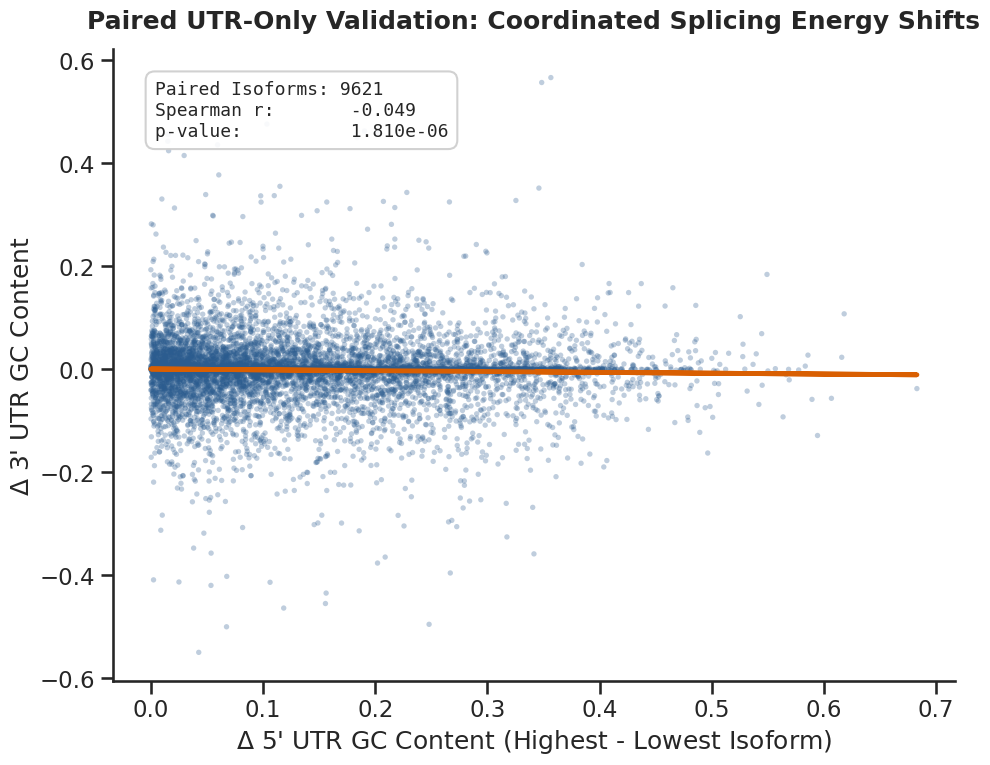

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from scipy.stats import spearmanr

sns.set_theme(style="ticks", context="talk")
plt.rcParams['font.family'] = 'sans-serif'

# 1. Target the pure UTR sequence composition features
gene_id_col = 'gene_id'
utr5_gc_col = '5_UTR_GC'
utr3_gc_col = '3_UTR_GC'

print(f"Total transcripts initially in all_df: {len(all_df)}")

# 2. Clean based purely on rows that have both UTR sequence profiles populated
clean_all_df = all_df.dropna(subset=[gene_id_col, utr5_gc_col, utr3_gc_col]).copy()

# Ensure they are evaluated as numeric values
clean_all_df[utr5_gc_col] = pd.to_numeric(clean_all_df[utr5_gc_col], errors='coerce')
clean_all_df[utr3_gc_col] = pd.to_numeric(clean_all_df[utr3_gc_col], errors='coerce')
clean_all_df = clean_all_df.dropna(subset=[utr5_gc_col, utr3_gc_col])

# 3. Identify multi-isoform genes with valid UTR pairs
isoform_counts = clean_all_df[gene_id_col].value_counts()
multi_isoform_genes = isoform_counts[isoform_counts >= 2].index
paired_candidates = clean_all_df[clean_all_df[gene_id_col].isin(multi_isoform_genes)]

print(f"Found {len(multi_isoform_genes)} unique genes with alternative dual-UTR profiles (comprising {len(paired_candidates)} rows).")

# 4. Extract Paired Differences
paired_signals = []
for gene, group in paired_candidates.groupby(gene_id_col):
    # Sort strictly by 5' UTR GC content to anchor the delta boundaries
    group_sorted = group.sort_values(by=utr5_gc_col)
    
    delta_5_gc = group_sorted[utr5_gc_col].iloc[-1] - group_sorted[utr5_gc_col].iloc[0]
    
    if delta_5_gc == 0:
        continue
        
    # Calculate how the 3' UTR GC content shifts in response
    delta_3_gc = group_sorted[utr3_gc_col].iloc[-1] - group_sorted[utr3_gc_col].iloc[0]
    
    paired_signals.append({
        'gene_id': gene,
        'delta_5_UTR_GC': delta_5_gc,
        'delta_3_UTR_GC': delta_3_gc
    })

paired_signal_df = pd.DataFrame(paired_signals)

# 5. Plotting and Statistical Validation
if len(paired_signal_df) > 0:
    plot_df = paired_signal_df[['delta_5_UTR_GC', 'delta_3_UTR_GC']].dropna()
    
    x_data = plot_df['delta_5_UTR_GC'].to_numpy()
    y_data = plot_df['delta_3_UTR_GC'].to_numpy()
    
    plt.figure(figsize=(10, 8))
    plt.scatter(x=x_data, y=y_data, color="#2b5c8f", alpha=0.3, s=15, edgecolors='none')
    
    if len(plot_df) > 1 and np.std(y_data) != 0:
        m, b = np.polyfit(x_data, y_data, 1)
        plt.plot(x_data, m*x_data + b, color="#d95f02", lw=3.5, label='Coordinated Trend')
    
    r_val, p_val = spearmanr(x_data, y_data)
    
    stats_box = (
        f"Paired Isoforms: {len(plot_df)}\n"
        f"Spearman r:       {r_val:.3f}\n"
        f"p-value:          {p_val:.3e}"
    )
    plt.gca().text(
        0.05, 0.95, stats_box,
        transform=plt.gca().transAxes,
        fontsize=13,
        fontfamily='monospace',
        verticalalignment='top',
        horizontalalignment='left',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.9, edgecolor='#cccccc')
    )
    
    plt.xlabel("$\Delta$ 5' UTR GC Content (Highest - Lowest Isoform)")
    plt.ylabel("$\Delta$ 3' UTR GC Content")
    plt.title("Paired UTR-Only Validation: Coordinated Splicing Energy Shifts", pad=15, weight='bold')
    
    sns.despine()
    plt.tight_layout()
    plt.show()
else:
    print("Error: The alternative isoforms do not have populated 5_UTR_GC or 3_UTR_GC values.")

Successfully mapped sequence profiles and baseline GC for 9650 unique genes.


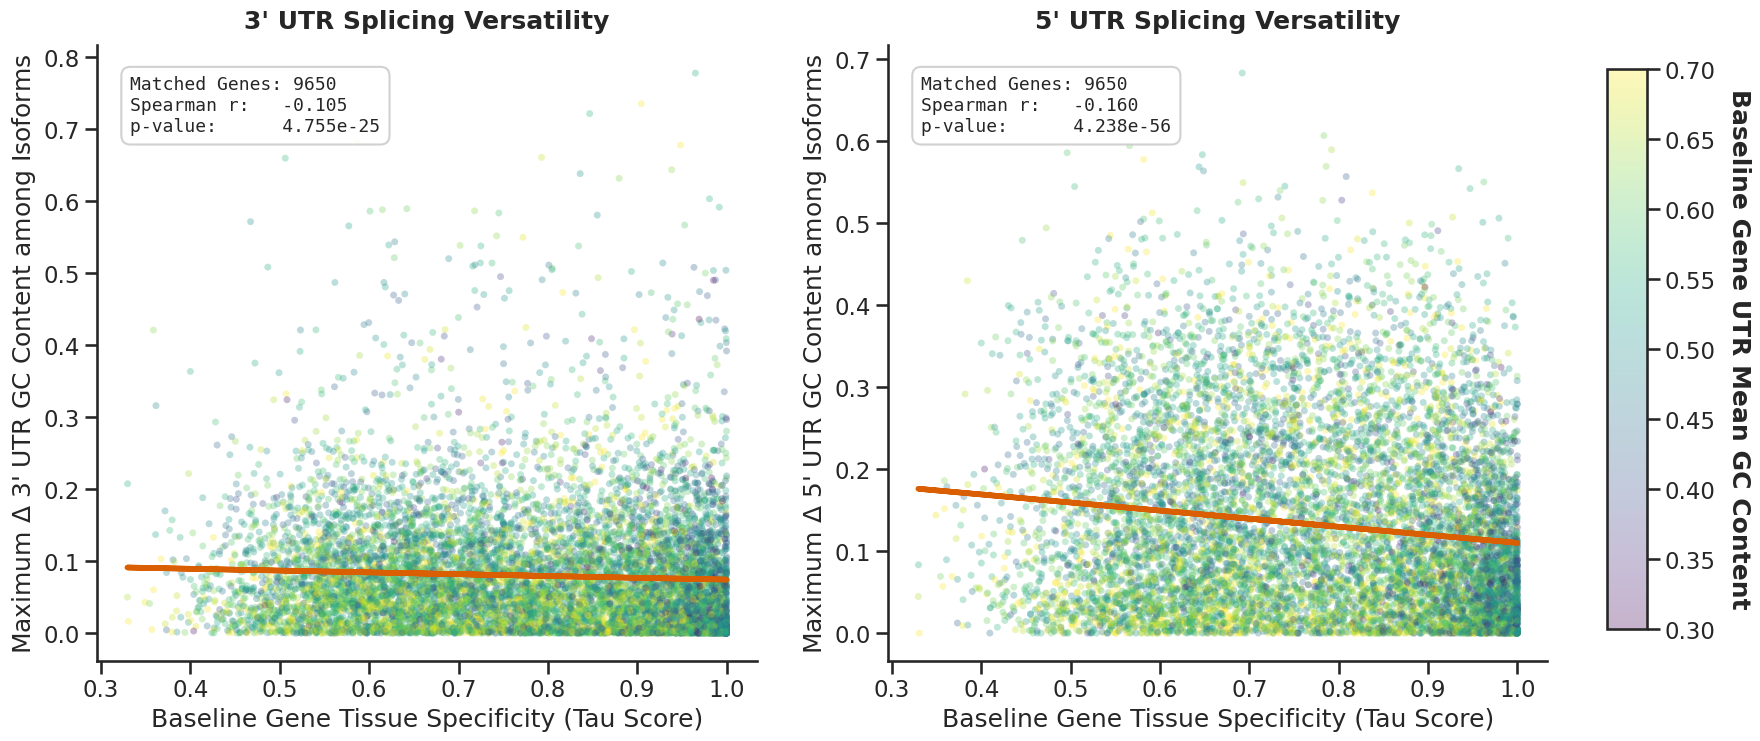

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from scipy.stats import spearmanr

sns.set_theme(style="ticks", context="talk")
plt.rcParams['font.family'] = 'sans-serif'

# 1. Standardize tracking column names
gene_id_col = 'gene_id'
utr5_gc_col = '5_UTR_GC'
utr3_gc_col = '3_UTR_GC'

final_gene_id = 'ENSG_ID' if 'ENSG_ID' in unique_df.columns else ('gene_id' if 'gene_id' in unique_df.columns else 'gene')
final_tau = 'tau_score' if 'tau_score' in unique_df.columns else ('tau' if 'tau' in unique_df.columns else 'tau_score')

# 2. Extract the paired UTR differences from all_df
clean_all_df = all_df.dropna(subset=[gene_id_col, utr5_gc_col, utr3_gc_col]).copy()
clean_all_df[utr5_gc_col] = pd.to_numeric(clean_all_df[utr5_gc_col], errors='coerce')
clean_all_df[utr3_gc_col] = pd.to_numeric(clean_all_df[utr3_gc_col], errors='coerce')
clean_all_df = clean_all_df.dropna(subset=[utr5_gc_col, utr3_gc_col])

isoform_counts = clean_all_df[gene_id_col].value_counts()
multi_isoform_genes = isoform_counts[isoform_counts >= 2].index
paired_candidates = clean_all_df[clean_all_df[gene_id_col].isin(multi_isoform_genes)]

paired_signals = []
for gene, group in paired_candidates.groupby(gene_id_col):
    delta_5_gc = group[utr5_gc_col].max() - group[utr5_gc_col].min()
    delta_3_gc = group[utr3_gc_col].max() - group[utr3_gc_col].min()
    
    paired_signals.append({
        'gene_id': gene,
        'delta_5_UTR_GC': delta_5_gc,
        'delta_3_UTR_GC': delta_3_gc
    })

paired_df = pd.DataFrame(paired_signals)
paired_df['match_id'] = paired_df['gene_id'].astype(str).str.split('.').str[0]

# 3. Pull both Tau and baseline UTR GC properties from unique_df
unique_df_copy = unique_df.dropna(subset=[final_gene_id, final_tau]).copy()
unique_df_copy['match_id'] = unique_df_copy[final_gene_id].astype(str).str.split('.').str[0]

unique_df_copy[utr5_gc_col] = pd.to_numeric(unique_df_copy[utr5_gc_col], errors='coerce')
unique_df_copy[utr3_gc_col] = pd.to_numeric(unique_df_copy[utr3_gc_col], errors='coerce')
unique_df_copy['baseline_mean_UTR_GC'] = unique_df_copy[[utr5_gc_col, utr3_gc_col]].mean(axis=1)

tau_map = unique_df_copy.set_index('match_id')[final_tau].to_dict()
gc_map = unique_df_copy.dropna(subset=['baseline_mean_UTR_GC']).set_index('match_id')['baseline_mean_UTR_GC'].to_dict()

paired_df['tau_score'] = paired_df['match_id'].map(tau_map)
paired_df['baseline_gc'] = paired_df['match_id'].map(gc_map)

plot_df = paired_df.dropna(subset=['tau_score', 'baseline_gc']).copy()
print(f"Successfully mapped sequence profiles and baseline GC for {len(plot_df)} unique genes.")

# 4. Side-by-Side Plotting with Color Scaling
if len(plot_df) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(20, 8), sharex=True)
    
    x_data = plot_df['tau_score'].to_numpy()
    color_data = plot_df['baseline_gc'].to_numpy()
    
    color_map = 'viridis'
    vmin, vmax = 0.3, 0.7  # Clamping standard UTR GC ranges
    
    # ------------------ PANEL 1: 3' UTR VERSATILITY (LEFT) ------------------
    y_data_3 = plot_df['delta_3_UTR_GC'].to_numpy()
    scatter3 = axes[0].scatter(
        x=x_data, y=y_data_3, c=color_data, cmap=color_map, 
        vmin=vmin, vmax=vmax, alpha=0.3, s=25, edgecolors='none'
    )
    
    m3, b3 = np.polyfit(x_data, y_data_3, 1)
    axes[0].plot(x_data, m3*x_data + b3, color="#d95f02", lw=4, label='Trend')
    
    r_val3, p_val3 = spearmanr(x_data, y_data_3)
    stats_str3 = f"Matched Genes: {len(plot_df)}\nSpearman r:   {r_val3:.3f}\np-value:      {p_val3:.3e}"
    
    # FIX: Added back positional arguments x, y, and s
    axes[0].text(
        0.05, 0.95, stats_str3,
        transform=axes[0].transAxes, fontsize=13, fontfamily='monospace', verticalalignment='top',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.9, edgecolor='#cccccc')
    )
    axes[0].set_xlabel("Baseline Gene Tissue Specificity (Tau Score)")
    axes[0].set_ylabel("Maximum $\Delta$ 3' UTR GC Content among Isoforms")
    axes[0].set_title("3' UTR Splicing Versatility", weight='bold', pad=12)
    
    # ------------------ PANEL 2: 5' UTR VERSATILITY (RIGHT) ------------------
    y_data_5 = plot_df['delta_5_UTR_GC'].to_numpy()
    scatter5 = axes[1].scatter(
        x=x_data, y=y_data_5, c=color_data, cmap=color_map, 
        vmin=vmin, vmax=vmax, alpha=0.3, s=25, edgecolors='none'
    )
    
    m5, b5 = np.polyfit(x_data, y_data_5, 1)
    axes[1].plot(x_data, m5*x_data + b5, color="#d95f02", lw=4)
    
    r_val5, p_val5 = spearmanr(x_data, y_data_5)
    stats_str5 = f"Matched Genes: {len(plot_df)}\nSpearman r:   {r_val5:.3f}\np-value:      {p_val5:.3e}"
    
    # FIX: Added back positional arguments x, y, and s
    axes[1].text(
        0.05, 0.95, stats_str5,
        transform=axes[1].transAxes, fontsize=13, fontfamily='monospace', verticalalignment='top',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.9, edgecolor='#cccccc')
    )
    axes[1].set_xlabel("Baseline Gene Tissue Specificity (Tau Score)")
    axes[1].set_ylabel("Maximum $\Delta$ 5' UTR GC Content among Isoforms")
    axes[1].set_title("5' UTR Splicing Versatility", weight='bold', pad=12)
    
    # ------------------ COLORBAR SETUP ------------------
    fig.subplots_adjust(right=0.85)
    cbar_ax = fig.add_axes([0.88, 0.15, 0.02, 0.7])
    cbar = fig.colorbar(scatter5, cax=cbar_ax)
    cbar.set_label("Baseline Gene UTR Mean GC Content", rotation=270, labelpad=25, weight='bold')
    
    sns.despine(ax=axes[0])
    sns.despine(ax=axes[1])
    
    plt.savefig("utr_splicing_versatility_gc_gradient.png", bbox_inches='tight', dpi=300)
    plt.show()
else:
    print("Error: No overlapping matches found. Verify GC mapping formatting.")

Successfully aligned UTR profiles, Tau scores, and region lengths for 9650 genes.


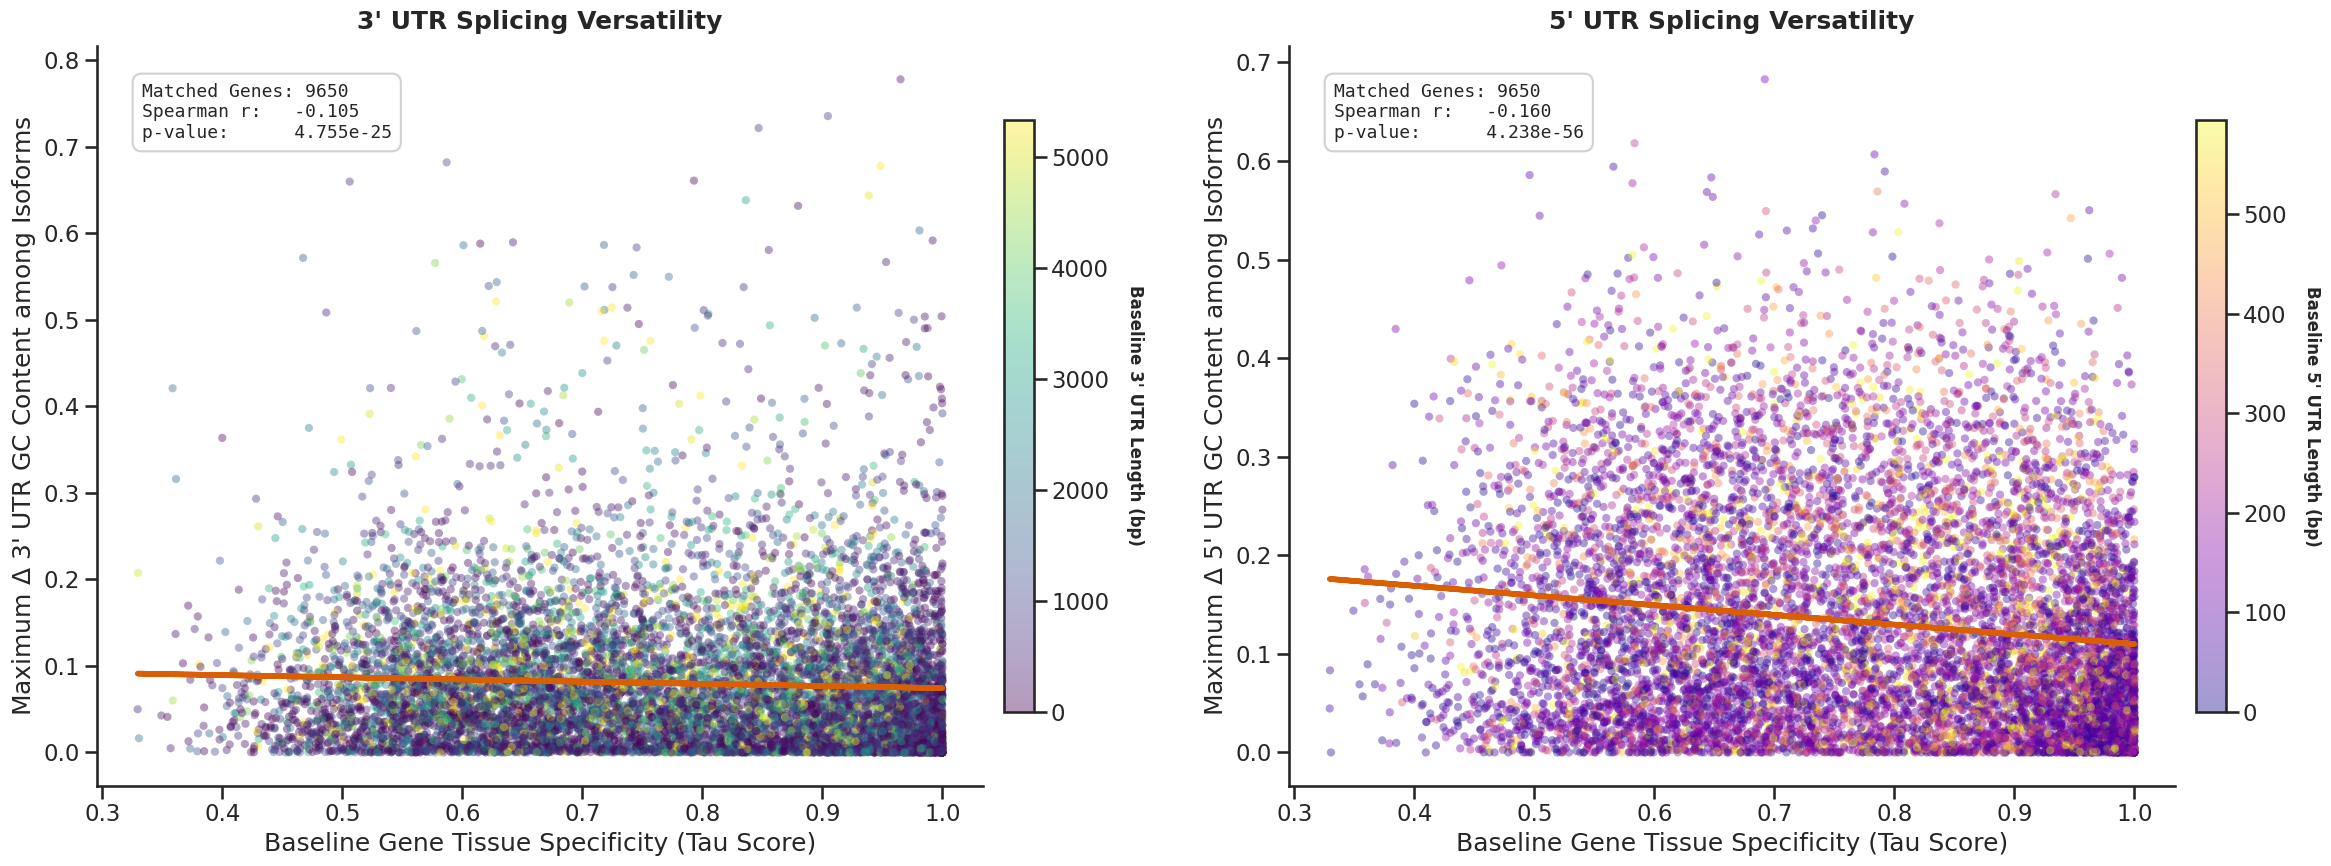

In [28]:
gene_id_col = 'gene_id'
utr5_gc_col = '5_UTR_GC'
utr3_gc_col = '3_UTR_GC'

final_gene_id = 'ENSG_ID' if 'ENSG_ID' in unique_df.columns else ('gene_id' if 'gene_id' in unique_df.columns else 'gene')
final_tau = 'tau_score' if 'tau_score' in unique_df.columns else ('tau' if 'tau' in unique_df.columns else 'tau_score')

# Dynamic check for UTR length columns in unique_sequences.csv
len5_col = next((c for c in unique_df.columns if c.lower() in ['5_utr_len', '5_utr_length', 'utr5_len', 'utr5_length']), None)
len3_col = next((c for c in unique_df.columns if c.lower() in ['3_utr_len', '3_utr_length', 'utr3_len', 'utr3_length']), None)

if not len5_col or not len3_col:
    print(f"Warning: Could not auto-detect length columns. Detected columns: {list(unique_df.columns)}")
    # Fallback placeholders—adjust these strings if your headers differ
    len5_col = '5_UTR_len' if '5_UTR_len' in unique_df.columns else '5_UTR_length'
    len3_col = '3_UTR_len' if '3_UTR_len' in unique_df.columns else '3_UTR_length'

# ==============================================================================
# 2. EXTRACT SPLICED UTR DYNAMICS FROM all_df
# ==============================================================================
clean_all_df = all_df.dropna(subset=[gene_id_col, utr5_gc_col, utr3_gc_col]).copy()
clean_all_df[utr5_gc_col] = pd.to_numeric(clean_all_df[utr5_gc_col], errors='coerce')
clean_all_df[utr3_gc_col] = pd.to_numeric(clean_all_df[utr3_gc_col], errors='coerce')
clean_all_df = clean_all_df.dropna(subset=[utr5_gc_col, utr3_gc_col])

isoform_counts = clean_all_df[gene_id_col].value_counts()
multi_isoform_genes = isoform_counts[isoform_counts >= 2].index
paired_candidates = clean_all_df[clean_all_df[gene_id_col].isin(multi_isoform_genes)]

paired_signals = []
for gene, group in paired_candidates.groupby(gene_id_col):
    delta_5_gc = group[utr5_gc_col].max() - group[utr5_gc_col].min()
    delta_3_gc = group[utr3_gc_col].max() - group[utr3_gc_col].min()
    
    paired_signals.append({
        'gene_id': gene,
        'delta_5_UTR_GC': delta_5_gc,
        'delta_3_UTR_GC': delta_3_gc
    })

paired_df = pd.DataFrame(paired_signals)
paired_df['match_id'] = paired_df['gene_id'].astype(str).str.split('.').str[0]

# ==============================================================================
# 3. MAP TAU SCORE AND REGION-SPECIFIC LENGTHS FROM unique_df
# ==============================================================================
unique_df['match_id'] = unique_df[final_gene_id].astype(str).str.split('.').str[0]

# Safe numeric conversion for lengths
unique_df[len5_col] = pd.to_numeric(unique_df[len5_col], errors='coerce')
unique_df[len3_col] = pd.to_numeric(unique_df[len3_col], errors='coerce')

tau_map = unique_df.dropna(subset=[final_tau]).set_index('match_id')[final_tau].to_dict()
len5_map = unique_df.dropna(subset=[len5_col]).set_index('match_id')[len5_col].to_dict()
len3_map = unique_df.dropna(subset=[len3_col]).set_index('match_id')[len3_col].to_dict()

paired_df['tau_score'] = paired_df['match_id'].map(tau_map)
paired_df['utr5_length'] = paired_df['match_id'].map(len5_map)
paired_df['utr3_length'] = paired_df['match_id'].map(len3_map)

plot_df = paired_df.dropna(subset=['tau_score', 'utr5_length', 'utr3_length']).copy()
print(f"Successfully aligned UTR profiles, Tau scores, and region lengths for {len(plot_df)} genes.")

# ==============================================================================
# 4. SIDE-BY-SIDE VISUALIZATION WITH INDEPENDENT COLORBARS
# ==============================================================================
if len(plot_df) > 0:
    # Creating a custom grid layout to house two distinct colorbars cleanly
    fig, axes = plt.subplots(1, 2, figsize=(24, 9), sharex=True)
    
    x_data = plot_df['tau_score'].to_numpy()
    
    # Use 95th percentile clipping for color scales to stop massive outlier UTRs from washing out the gradient
    vmax_3 = np.percentile(plot_df['utr3_length'], 95)
    vmax_5 = np.percentile(plot_df['utr5_length'], 95)
    
    # ------------------ PANEL 1: 3' UTR VERSATILITY (COLOR = 3' UTR LENGTH) ------------------
    y_data_3 = plot_df['delta_3_UTR_GC'].to_numpy()
    color_3 = plot_df['utr3_length'].to_numpy()
    
    scatter3 = axes[0].scatter(
        x=x_data, y=y_data_3, c=color_3, cmap='viridis', 
        vmin=0, vmax=vmax_3, alpha=0.4, s=35, edgecolors='none'
    )
    
    m3, b3 = np.polyfit(x_data, y_data_3, 1)
    axes[0].plot(x_data, m3*x_data + b3, color="#d95f02", lw=4)
    
    r_val3, p_val3 = spearmanr(x_data, y_data_3)
    axes[0].text(
        0.05, 0.95, f"Matched Genes: {len(plot_df)}\nSpearman r:   {r_val3:.3f}\np-value:      {p_val3:.3e}",
        transform=axes[0].transAxes, fontsize=13, fontfamily='monospace', verticalalignment='top',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.9, edgecolor='#cccccc')
    )
    axes[0].set_xlabel("Baseline Gene Tissue Specificity (Tau Score)")
    axes[0].set_ylabel("Maximum $\Delta$ 3' UTR GC Content among Isoforms")
    axes[0].set_title("3' UTR Splicing Versatility", weight='bold', pad=12)
    
    # Append standalone colorbar for 3' UTR Length
    cbar3 = fig.colorbar(scatter3, ax=axes[0], pad=0.02, shrink=0.8)
    cbar3.set_label("Baseline 3' UTR Length (bp)", rotation=270, labelpad=25, weight='bold', fontsize=12)
    
    # ------------------ PANEL 2: 5' UTR VERSATILITY (COLOR = 5' UTR LENGTH) ------------------
    y_data_5 = plot_df['delta_5_UTR_GC'].to_numpy()
    color_5 = plot_df['utr5_length'].to_numpy()
    
    scatter5 = axes[1].scatter(
        x=x_data, y=y_data_5, c=color_5, cmap='plasma', 
        vmin=0, vmax=vmax_5, alpha=0.4, s=35, edgecolors='none'
    )
    
    m5, b5 = np.polyfit(x_data, y_data_5, 1)
    axes[1].plot(x_data, m5*x_data + b5, color="#d95f02", lw=4)
    
    r_val5, p_val5 = spearmanr(x_data, y_data_5)
    axes[1].text(
        0.05, 0.95, f"Matched Genes: {len(plot_df)}\nSpearman r:   {r_val5:.3f}\np-value:      {p_val5:.3e}",
        transform=axes[1].transAxes, fontsize=13, fontfamily='monospace', verticalalignment='top',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.9, edgecolor='#cccccc')
    )
    axes[1].set_xlabel("Baseline Gene Tissue Specificity (Tau Score)")
    axes[1].set_ylabel("Maximum $\Delta$ 5' UTR GC Content among Isoforms")
    axes[1].set_title("5' UTR Splicing Versatility", weight='bold', pad=12)
    
    # Append standalone colorbar for 5' UTR Length
    cbar5 = fig.colorbar(scatter5, ax=axes[1], pad=0.02, shrink=0.8)
    cbar5.set_label("Baseline 5' UTR Length (bp)", rotation=270, labelpad=25, weight='bold', fontsize=12)
    
    # ------------------ GLOBAL SETTINGS ------------------
    sns.despine(ax=axes[0])
    sns.despine(ax=axes[1])
    plt.tight_layout()
    
    plt.savefig("utr_length_vs_composition_shifts.png", bbox_inches='tight', dpi=300)
    plt.show()
else:
    print("Execution complete: Please verify your unique_sequences.csv length headers.")

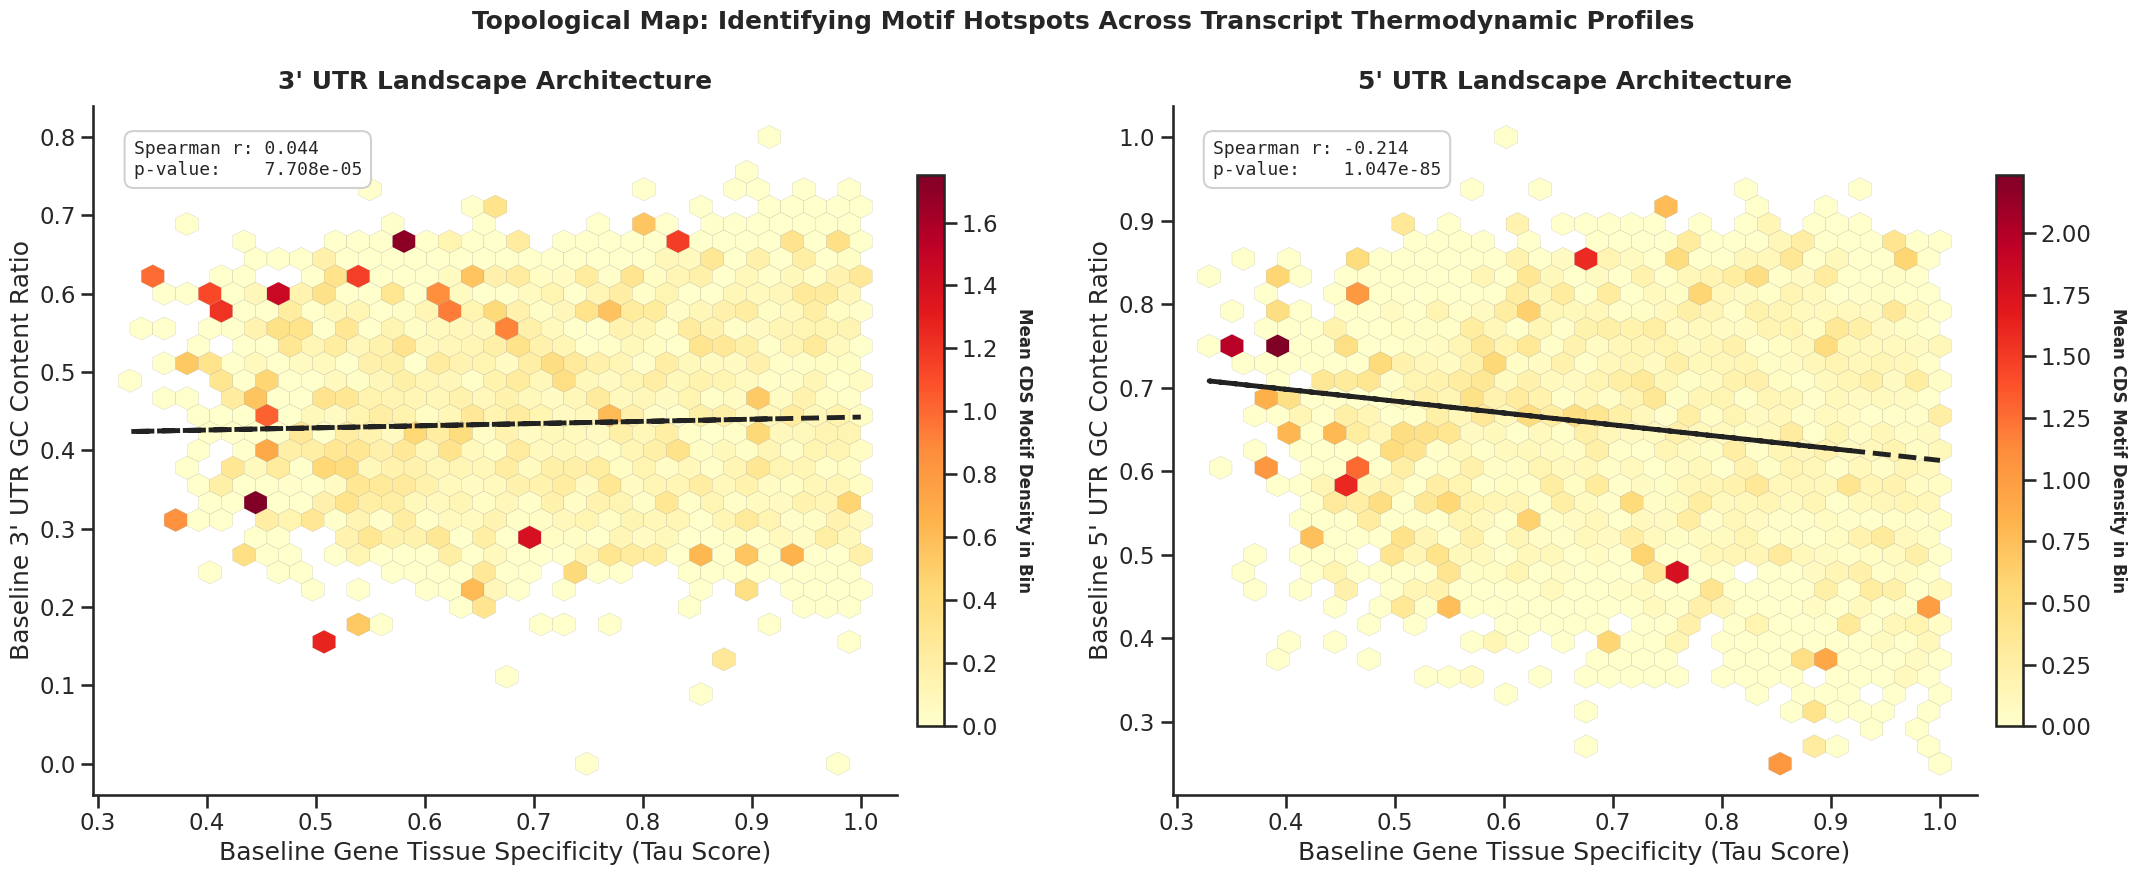

In [37]:
gene_id_col = 'gene_id'
utr5_gc_col = '5_UTR_GC'
utr3_gc_col = '3_UTR_GC'

final_gene_id = 'ENSG_ID' if 'ENSG_ID' in unique_df.columns else ('gene_id' if 'gene_id' in unique_df.columns else 'gene')
final_tau = 'tau_score' if 'tau_score' in unique_df.columns else ('tau' if 'tau' in unique_df.columns else 'tau_score')
cds_len_col = next((c for c in unique_df.columns if c.lower() in ['cds_len', 'cds_length', 'cds_len_bp']), None)

# ==============================================================================
# 2. COMPUTE SYSTEMIC CDS MOTIF DENSITY
# ==============================================================================
def count_total_motifs(motifs_entry):
    if pd.isna(motifs_entry) or str(motifs_entry).strip() in ['', '[]', 'None']:
        return 0
    return len(str(motifs_entry).split(','))

unique_df['total_motif_count'] = unique_df['Motif'].apply(count_total_motifs)
unique_df['match_id'] = unique_df[final_gene_id].astype(str).str.split('.').str[0]

if cds_len_col:
    unique_df[cds_len_col] = pd.to_numeric(unique_df[cds_len_col], errors='coerce')
    unique_df['motif_density'] = (unique_df['total_motif_count'] / unique_df[cds_len_col].replace(0, np.nan)) * 1000
else:
    unique_df['motif_density'] = unique_df['total_motif_count']

# ==============================================================================
# 3. BUILD MAPPING DICTIONARIES & ISOLATE COHORTS
# ==============================================================================
unique_df[utr5_gc_col] = pd.to_numeric(unique_df[utr5_gc_col], errors='coerce')
unique_df[utr3_gc_col] = pd.to_numeric(unique_df[utr3_gc_col], errors='coerce')

tau_map = unique_df.dropna(subset=[final_tau]).set_index('match_id')[final_tau].to_dict()
gc5_map = unique_df.dropna(subset=[utr5_gc_col]).set_index('match_id')[utr5_gc_col].to_dict()
gc3_map = unique_df.dropna(subset=[utr3_gc_col]).set_index('match_id')[utr3_gc_col].to_dict()
motif_density_map = unique_df.set_index('match_id')['motif_density'].to_dict()

isoform_counts = all_df[gene_id_col].value_counts()
multi_isoform_genes = isoform_counts[isoform_counts >= 2].index

paired_df = pd.DataFrame({'gene_id': multi_isoform_genes})
paired_df['match_id'] = paired_df['gene_id'].astype(str).str.split('.').str[0]

paired_df['tau_score'] = paired_df['match_id'].map(tau_map)
paired_df['utr5_gc'] = paired_df['match_id'].map(gc5_map)
paired_df['utr3_gc'] = paired_df['match_id'].map(gc3_map)
paired_df['cds_motif_density'] = paired_df['match_id'].map(motif_density_map).fillna(0)

plot_df = paired_df.dropna(subset=['tau_score', 'utr5_gc', 'utr3_gc']).copy()

# ==============================================================================
# 4. HIGH-CLARITY BINNED MACRO-MAPS
# ==============================================================================
if len(plot_df) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(22, 9), sharex=True)
    
    x_data = plot_df['tau_score'].to_numpy()
    z_data = plot_df['cds_motif_density'].to_numpy()
    
    # Grid granularity parameter (Higher number = smaller hexagons)
    grid_size = 32
    
    # ------------------ PANEL 1: 3' UTR ARCHITECTURE MAP ------------------
    y_data_3 = plot_df['utr3_gc'].to_numpy()
    
    # Corrected: use 'reduce_C_function' instead of 'reduce'
    hb3 = axes[0].hexbin(
        x_data, y_data_3, C=z_data, reduce_C_function=np.mean, gridsize=grid_size,
        cmap='YlOrRd', mincnt=1, edgecolors='gray', linewidths=0.1
    )
    
    m3, b3 = np.polyfit(x_data, y_data_3, 1)
    axes[0].plot(x_data, m3*x_data + b3, color="#222222", lw=3.5, linestyle='--')
    
    r_val3, p_val3 = spearmanr(x_data, y_data_3)
    axes[0].text(
        0.05, 0.95, f"Spearman r: {r_val3:.3f}\np-value:    {p_val3:.3e}",
        transform=axes[0].transAxes, fontsize=13, fontfamily='monospace', verticalalignment='top',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.9, edgecolor='#cccccc')
    )
    axes[0].set_xlabel("Baseline Gene Tissue Specificity (Tau Score)")
    axes[0].set_ylabel("Baseline 3' UTR GC Content Ratio")
    axes[0].set_title("3' UTR Landscape Architecture", weight='bold', pad=12)
    
    # Add clear, dedicated colorbar for Panel 1
    cbar3 = fig.colorbar(hb3, ax=axes[0], pad=0.02, shrink=0.8)
    cbar3.set_label("Mean CDS Motif Density in Bin", rotation=270, labelpad=25, weight='bold', fontsize=12)
    
    # ------------------ PANEL 2: 5' UTR ARCHITECTURE MAP ------------------
    y_data_5 = plot_df['utr5_gc'].to_numpy()
    
    # Corrected: use 'reduce_C_function' instead of 'reduce'
    hb5 = axes[1].hexbin(
        x_data, y_data_5, C=z_data, reduce_C_function=np.mean, gridsize=grid_size,
        cmap='YlOrRd', mincnt=1, edgecolors='gray', linewidths=0.1
    )
    
    m5, b5 = np.polyfit(x_data, y_data_5, 1)
    axes[1].plot(x_data, m5*x_data + b5, color="#222222", lw=3.5, linestyle='--')
    
    r_val5, p_val5 = spearmanr(x_data, y_data_5)
    axes[1].text(
        0.05, 0.95, f"Spearman r: {r_val5:.3f}\np-value:    {p_val5:.3e}",
        transform=axes[1].transAxes, fontsize=13, fontfamily='monospace', verticalalignment='top',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.9, edgecolor='#cccccc')
    )
    axes[1].set_xlabel("Baseline Gene Tissue Specificity (Tau Score)")
    axes[1].set_ylabel("Baseline 5' UTR GC Content Ratio")
    axes[1].set_title("5' UTR Landscape Architecture", weight='bold', pad=12)
    
    # Add clear, dedicated colorbar for Panel 2
    cbar5 = fig.colorbar(hb5, ax=axes[1], pad=0.02, shrink=0.8)
    cbar5.set_label("Mean CDS Motif Density in Bin", rotation=270, labelpad=25, weight='bold', fontsize=12)
    
    # ------------------ GLOBAL WRAPPER ------------------
    plt.suptitle("Topological Map: Identifying Motif Hotspots Across Transcript Thermodynamic Profiles", y=0.98, weight='bold', fontsize=18)
    sns.despine(ax=axes[0])
    sns.despine(ax=axes[1])
    plt.tight_layout()
    
    plt.savefig("binned_utr_motif_density_map.png", bbox_inches='tight', dpi=300)
    plt.show()

Rows with parsed motifs: 6188
Unique parsed motifs: 868
Motif ranking source: motif_summary (20 motifs)
{'all_df': 3094, 'unique_df': 3094}


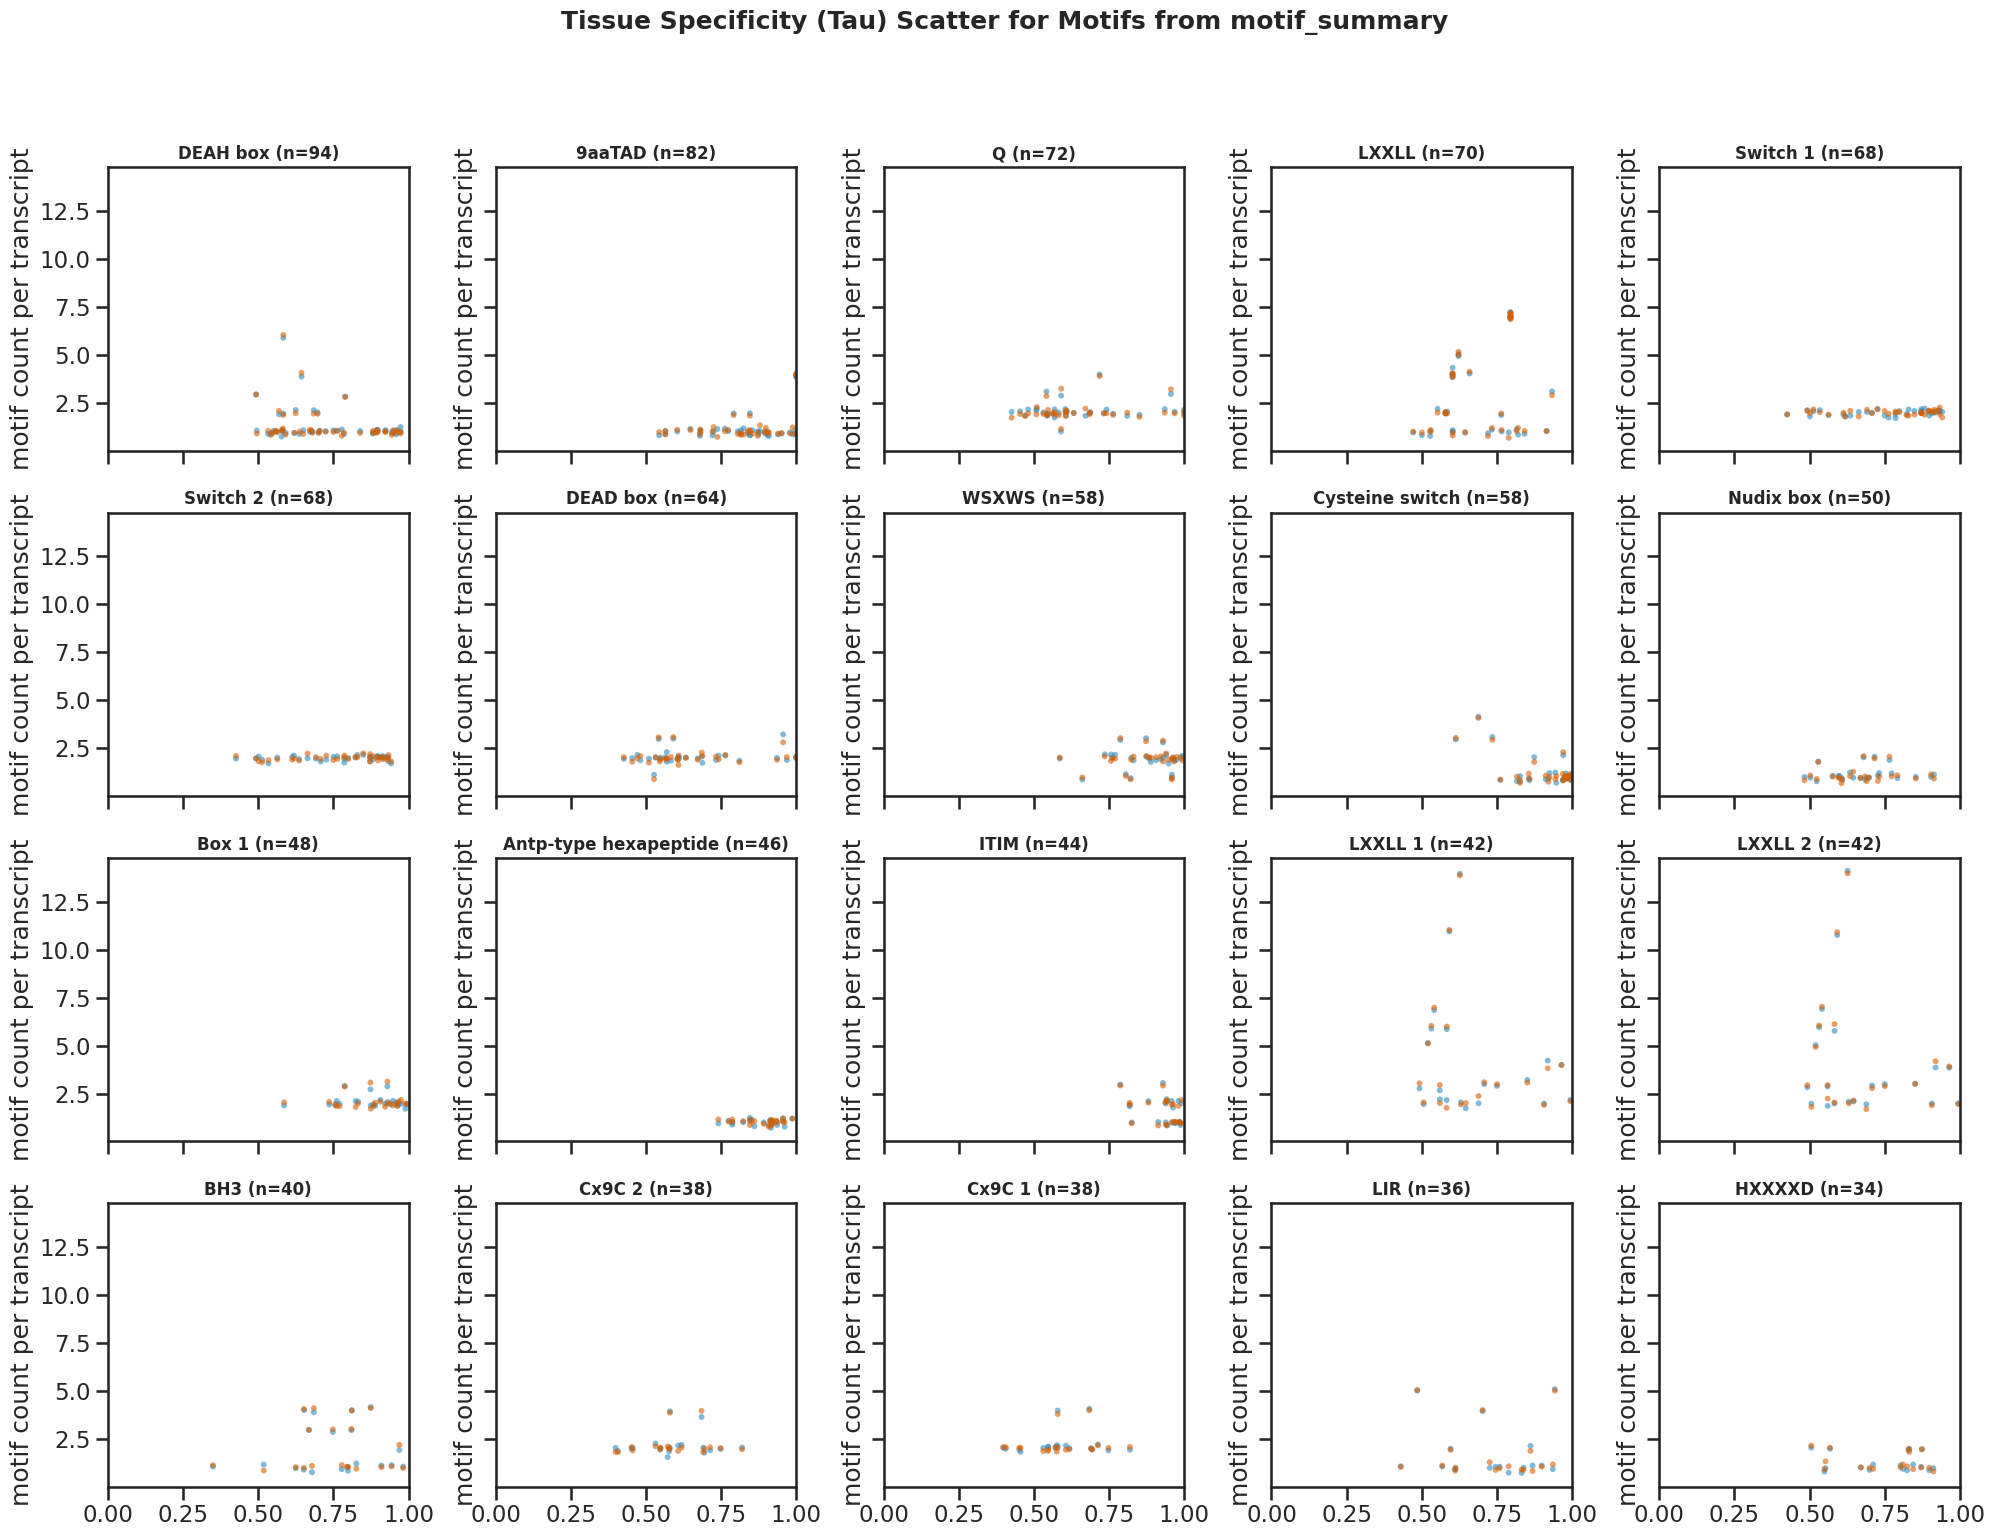

In [76]:
import re

# Compare the top motifs from motif_summary across all_df and unique_df.
all_df = all_df.copy()
unique_df = unique_df.copy()

motif_summary_col = next((c for c in ['Motif_List', 'Motif', 'motif'] if c in motif_summary.columns), None)
if motif_summary_col is None:
    raise KeyError("No motif column found in motif_summary.")

count_col = next((c for c in motif_summary.columns if c != motif_summary_col), None)
if count_col is None:
    raise KeyError("No count column found in motif_summary.")

top_20_motifs = (
    motif_summary.sort_values(count_col, ascending=False)[motif_summary_col]
    .head(20)
    .astype(str)
    .tolist()
)

motif_col = 'Motif' if 'Motif' in all_df.columns else ('Motifs' if 'Motifs' in all_df.columns else None)
if motif_col is None:
    raise KeyError("No motif column found in all_df.")

all_tau_col = next((c for c in ['tau_score', 'tau', 'Tau', 'Tau_score', 'tau_score_fixed'] if c in all_df.columns), None)
unique_tau_col = next((c for c in ['tau_score', 'tau', 'Tau', 'Tau_score', 'tau_score_fixed'] if c in unique_df.columns), None)
if all_tau_col is None and unique_tau_col is None:
    raise KeyError("No tau column found in all_df or unique_df.")


def parse_motifs(value):
    if pd.isna(value):
        return []

    if isinstance(value, (list, tuple, set)):
        raw_items = list(value)
    else:
        text = str(value).strip()
        if not text:
            return []
        matches = re.findall(r'MOTIF\b.*?/note\s*=\s*"([^"]+)"', text, flags=re.IGNORECASE | re.DOTALL)
        raw_items = matches if matches else re.split(r'[;,]', text)

    cleaned = []
    for item in raw_items:
        token = str(item).strip()
        token = token.strip('"\'')
        token = re.sub(r'(?i)\bmotif\b', '', token)
        token = re.sub(r'\s+', ' ', token).strip()
        token = re.sub(r'^[\s\-:;,\.]+', '', token)
        token = re.sub(r'[\s\-:;,\.]+$', '', token)
        if token and token.lower() != 'nuclear localization signal':
            cleaned.append(token)
    return cleaned


def build_motif_table(df, source_name):
    table = df.copy()
    table['Motif_List'] = table[motif_col].apply(parse_motifs)
    table['motif_count'] = table['Motif_List'].apply(len)
    table = table.explode('Motif_List')
    table['Motif_List'] = table['Motif_List'].astype(str).str.strip()
    table = table[table['Motif_List'].notna() & table['Motif_List'].ne('')]
    if all_tau_col is not None and all_tau_col in table.columns:
        table['tau_score'] = pd.to_numeric(table[all_tau_col], errors='coerce')
    elif unique_tau_col is not None and unique_tau_col in table.columns:
        table['tau_score'] = pd.to_numeric(table[unique_tau_col], errors='coerce')
    else:
        table['tau_score'] = np.nan
    table['source_group'] = source_name
    return table[['Motif_List', 'tau_score', 'motif_count', 'source_group']].dropna(subset=['tau_score'])


all_motif_df = build_motif_table(all_df, 'all_df')
unique_motif_df = build_motif_table(unique_df, 'unique_df')
analysis_df = pd.concat([all_motif_df, unique_motif_df], ignore_index=True)

print(f"Rows with parsed motifs: {len(analysis_df)}")
print(f"Unique parsed motifs: {analysis_df['Motif_List'].nunique()}")
print(f"Motif ranking source: motif_summary ({len(top_20_motifs)} motifs)")
print(analysis_df['source_group'].value_counts(dropna=False).to_dict())

present_top_motifs = [m for m in top_20_motifs if m in set(analysis_df['Motif_List'])]
if not present_top_motifs:
    present_top_motifs = analysis_df['Motif_List'].value_counts().head(20).index.tolist()
    print("None of the motif_summary motifs matched after parsing; using the 20 most common parsed motifs instead.")

fig, axes = plt.subplots(4, 5, figsize=(20, 16), sharex=True, sharey=True)
axes = axes.flatten()
color_map = {'all_df': '#2b8cbe', 'unique_df': '#d95f02'}
rng = np.random.default_rng(42)


for i, motif in enumerate(present_top_motifs):
    ax = axes[i]
    subset = analysis_df[analysis_df['Motif_List'] == motif].copy()
    for group_name in ['all_df', 'unique_df']:
        group_subset = subset[subset['source_group'] == group_name]
        if len(group_subset) > 0:
            y_jitter = group_subset['motif_count'].to_numpy() + rng.normal(0.0, 0.12, size=len(group_subset))
            ax.scatter(
                group_subset['tau_score'],
                y_jitter,
                s=18,
                alpha=0.6,
                color=color_map[group_name],
                edgecolors='none',
            )
    ax.set_title(f"{motif} (n={len(subset)})", fontsize=12, fontweight='bold')
    ax.set_xlim(0, 1)
    ax.set_ylabel('motif count per transcript')

for j in range(len(present_top_motifs), len(axes)):
    axes[j].axis('off')

plt.suptitle('Tissue Specificity (Tau) Scatter for Motifs from motif_summary', fontsize=18, fontweight='bold', y=0.995)
plt.tight_layout(rect=[0, 0.03, 1, 0.96])
plt.show()

In [ ]:
import re

# Compare the top interactors from interactors_summary across all_df and unique_df.
all_df = all_df.copy()
unique_df = unique_df.copy()

interactor_summary_col = next((c for c in ['Interactor', 'interactor', 'Interactor_List'] if c in interactors_summary.columns), None)
if interactor_summary_col is None:
    raise KeyError("No interactor column found in interactors_summary.")

count_col = next((c for c in interactors_summary.columns if c != interactor_summary_col), None)
if count_col is None:
    raise KeyError("No count column found in interactors_summary.")

top_20_interactors = (
    interactors_summary.sort_values(count_col, ascending=False)[interactor_summary_col]
    .head(20)
    .astype(str)
    .tolist()
)

interactor_col = next((c for c in ['Interacts with', 'Interacts_with', 'interacts_with', 'interactors'] if c in all_df.columns), None)
if interactor_col is None:
    raise KeyError("No interactor column found in all_df.")

all_tau_col = next((c for c in ['tau_score', 'tau', 'Tau', 'Tau_score', 'tau_score_fixed'] if c in all_df.columns), None)
unique_tau_col = next((c for c in ['tau_score', 'tau', 'Tau', 'Tau_score', 'tau_score_fixed'] if c in unique_df.columns), None)
if all_tau_col is None and unique_tau_col is None:
    raise KeyError("No tau column found in all_df or unique_df.")


def parse_interactors(value):
    if pd.isna(value):
        return []

    if isinstance(value, (list, tuple, set)):
        raw_items = list(value)
    else:
        text = str(value).strip()
        if not text:
            return []
        raw_items = re.split(r'[;,|]', text)

    cleaned = []
    for item in raw_items:
        token = str(item).strip()
        token = re.sub(r'\s+', ' ', token).strip()
        token = re.sub(r'^[\s\-:]+', '', token)
        token = re.sub(r'[\s\-:]+$', '', token)
        if token:
            cleaned.append(token)
    return cleaned


def build_interactor_table(df, source_name):
    table = df.copy()
    table['Interactor_List'] = table[interactor_col].apply(parse_interactors)
    table['interactor_count'] = table['Interactor_List'].apply(len)
    table = table.explode('Interactor_List')
    table['Interactor_List'] = table['Interactor_List'].astype(str).str.strip()
    table = table[table['Interactor_List'].notna() & table['Interactor_List'].ne('')]
    if all_tau_col is not None and all_tau_col in table.columns:
        table['tau_score'] = pd.to_numeric(table[all_tau_col], errors='coerce')
    elif unique_tau_col is not None and unique_tau_col in table.columns:
        table['tau_score'] = pd.to_numeric(table[unique_tau_col], errors='coerce')
    else:
        table['tau_score'] = np.nan
    table['source_group'] = source_name
    return table[['Interactor_List', 'tau_score', 'interactor_count', 'source_group']].dropna(subset=['tau_score'])


all_interactor_df = build_interactor_table(all_df, 'all_df')
unique_interactor_df = build_interactor_table(unique_df, 'unique_df')
interactor_analysis_df = pd.concat([all_interactor_df, unique_interactor_df], ignore_index=True)

print(f"Rows with parsed interactors: {len(interactor_analysis_df)}")
print(f"Unique parsed interactors: {interactor_analysis_df['Interactor_List'].nunique()}")
print(f"Interactor ranking source: interactors_summary ({len(top_20_interactors)} interactors)")
print(interactor_analysis_df['source_group'].value_counts(dropna=False).to_dict())

present_top_interactors = [x for x in top_20_interactors if x in set(interactor_analysis_df['Interactor_List'])]
if not present_top_interactors:
    present_top_interactors = interactor_analysis_df['Interactor_List'].value_counts().head(20).index.tolist()
    print("None of the interactors_summary entries matched after parsing; using the 20 most common parsed interactors instead.")

fig, axes = plt.subplots(4, 5, figsize=(20, 16), sharex=True, sharey=True)
axes = axes.flatten()
color_map = {'all_df': '#2b8cbe', 'unique_df': '#d95f02'}
rng = np.random.default_rng(42)

for i, interactor in enumerate(present_top_interactors):
    ax = axes[i]
    subset = interactor_analysis_df[interactor_analysis_df['Interactor_List'] == interactor].copy()
    for group_name in ['all_df', 'unique_df']:
        group_subset = subset[subset['source_group'] == group_name]
        if len(group_subset) > 0:
            y_jitter = group_subset['interactor_count'].to_numpy() + rng.normal(0.0, 0.12, size=len(group_subset))
            ax.scatter(
                group_subset['tau_score'],
                y_jitter,
                s=18,
                alpha=0.6,
                color=color_map[group_name],
                edgecolors='none',
            )
    ax.set_title(f"{interactor} (n={len(subset)})", fontsize=12, fontweight='bold')
    ax.set_xlim(0, 1)
    ax.set_ylabel('interactor count per transcript')

for j in range(len(present_top_interactors), len(axes)):
    axes[j].axis('off')

plt.suptitle('Tissue Specificity (Tau) Scatter for Interactors from interactors_summary', fontsize=18, fontweight='bold', y=0.995)
plt.tight_layout(rect=[0, 0.03, 1, 0.96])
plt.show()